# Segmentation → VNNLib property → ab-CROWN

Pipeline:

1. Load one image from a dataset (e.g. TinyImageNet).
2. Run a segmentation model (SAM2/SAM3) to get segments and bounding boxes.
3. Visualise boxes, manually pick one segment.
4. Use the bounding box to build a VNNLib property:
   - pixels *inside* the box: image ± ε
   - pixels *outside* the box: fixed to the original image value
5. (Optional) add robustness constraint for the true class.
6. Save `.vnnlib` file and run ab-CROWN.

1.	Tiny ImageNet is a smaller, 200-class subset of the ImageNet dataset, where each class contains 500 training images and 50 validation images.

2.	Every image is resized to 64×64 pixels, making the dataset lightweight and ideal for fast experiments, model prototyping, and academic assignments.


In [8]:
import os
from pathlib import Path
import zipfile
import urllib.request

# Where dataset will be stored
DATA_ROOT = Path("datasets/tiny-imagenet-200")

# Download URL
TIN_URL = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
ZIP_PATH = Path("tiny-imagenet-200.zip")

# Check if dataset exists
if not DATA_ROOT.exists():
    print("TinyImageNet not found. Downloading...")
    urllib.request.urlretrieve(TIN_URL, ZIP_PATH)
    print("Download complete!")

    print("Unzipping...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(".")
    print("Unzip complete.")

else:
    print("TinyImageNet already present.")

TinyImageNet already present.


Found 10000 validation images.
Selected image: datasets/tiny-imagenet-200/val/images/val_3119.JPEG


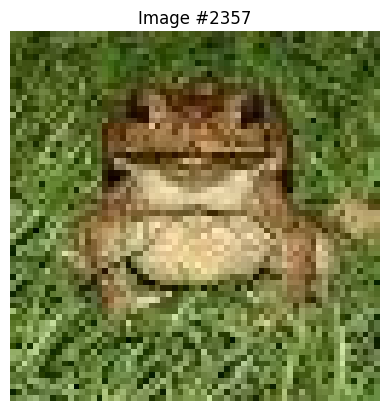

In [9]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

VAL_IMG_DIR = DATA_ROOT / "val" / "images"

# List all validation images
all_images = sorted(list(VAL_IMG_DIR.glob("*.JPEG")))
print(f"Found {len(all_images)} validation images.")

# Choose an index (you can change this number)
IMG_INDEX = 2357   # <<---- CHANGE THIS TO PICK ANOTHER IMAGE

IMG_PATH = all_images[IMG_INDEX]
print("Selected image:", IMG_PATH)

# Load image
image = Image.open(IMG_PATH).convert("RGB")
image_np = np.array(image) / 255.0

plt.imshow(image_np)
plt.axis("off")
plt.title(f"Image #{IMG_INDEX}")
plt.show()

In [11]:
from sam2.sam2_image_predictor import SAM2ImagePredictor
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

predictor = SAM2ImagePredictor.from_pretrained(
    "facebook/sam2-hiera-large",
    device=DEVICE,
)
predictor.model.eval();

In [ ]:
def run_segmentation_model(
    image_np: np.ndarray,
    grid_size: int = 6,
    iou_threshold: float = 0.8,
    score_threshold: float = 0.0,
):
    """
    Use SAM2ImagePredictor to get segments from an image.

    Returns:
        segments: list of dicts like
            {
                "bbox": [x_min, y_min, x_max, y_max],
                "mask": 2D boolean array (H, W)
            }
    """
    H, W, C = image_np.shape
    assert C == 3, "Expect RGB image (H, W, 3)"

    # ---- 1. prepare image for SAM2 ----
    img_uint8 = (np.clip(image_np, 0.0, 1.0) * 255).astype(np.uint8)
    predictor.set_image(img_uint8)

    # ---- 2. build a grid of foreground points as prompts ----
    ys = np.linspace(0, H - 1, grid_size).astype(int)
    xs = np.linspace(0, W - 1, grid_size).astype(int)
    grid_y, grid_x = np.meshgrid(ys, xs, indexing="ij")
    point_coords = np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)  # (P, 2)
    point_labels = np.ones(len(point_coords), dtype=np.int64)          # all FG

    masks, scores, logits = predictor.predict(
        point_coords=point_coords[None, ...],   # (1, P, 2)
        point_labels=point_labels[None, ...],   # (1, P)
        multimask_output=True,
    )

    # ---- 3. Normalize shapes (this is where things went wrong before) ----
    masks = np.array(masks)
    scores = np.array(scores)

    # Case A: (1, P, M, H, W)
    if masks.ndim == 5:
        _, P, M, Hm, Wm = masks.shape
        masks = masks.reshape(P * M, Hm, Wm)
        scores = scores.reshape(P * M)

    # Case B: (P, M, H, W)
    elif masks.ndim == 4:
        P, M, Hm, Wm = masks.shape
        masks = masks.reshape(P * M, Hm, Wm)
        scores = scores.reshape(P * M)

    # Case C: (K, H, W)  <-- this is your current case: (3, 64, 64)
    elif masks.ndim == 3:
        K, Hm, Wm = masks.shape
        # nothing to do, already (K, H, W)

    # Case D: (H, W) single mask
    elif masks.ndim == 2:
        Hm, Wm = masks.shape
        masks = masks[None, ...]
        scores = scores.reshape(1)

    else:
        raise ValueError(f"Unexpected SAM2 mask shape: {masks.shape}")

    # Sanity check spatial dims
    if masks.shape[-2:] != (H, W):
        raise ValueError(
            f"Mask spatial size {masks.shape[-2:]} != image size {(H, W)}"
        )

    # ---- 4. turn masks into segments + deduplicate via IoU ----
    def mask_iou(a, b):
        inter = np.logical_and(a, b).sum()
        union = np.logical_or(a, b).sum()
        if union == 0:
            return 0.0
        return inter / union

    segments = []
    for mask, score in zip(masks, scores):
        if score < score_threshold:
            continue

        ys_mask, xs_mask = np.where(mask)
        if len(ys_mask) == 0:
            continue

        y_min, y_max = ys_mask.min(), ys_mask.max() + 1
        x_min, x_max = xs_mask.min(), xs_mask.max() + 1

        keep = True
        for seg in segments:
            if mask_iou(mask, seg["mask"]) > iou_threshold:
                keep = False
                break
        if not keep:
            continue

        segments.append(
            {
                "bbox": [int(x_min), int(y_min), int(x_max), int(y_max)],
                "mask": mask.astype(bool),
            }
        )

    print(f"SAM2 produced {len(segments)} unique segments.")
    return segments

In [13]:
# Debug SAM2 output shapes
predictor.set_image((image_np * 255).astype(np.uint8))

ys = np.linspace(0, image_np.shape[0] - 1, 6).astype(int)
xs = np.linspace(0, image_np.shape[1] - 1, 6).astype(int)
grid_y, grid_x = np.meshgrid(ys, xs, indexing="ij")
point_coords = np.stack([grid_x.ravel(), grid_y.ravel()], axis=-1)
point_labels = np.ones(len(point_coords), dtype=np.int64)

masks, scores, logits = predictor.predict(
    point_coords=point_coords[None, ...],
    point_labels=point_labels[None, ...],
    multimask_output=True,
)

print("masks.shape:", np.array(masks).shape)
print("scores.shape:", np.array(scores).shape)
print("logits.shape:", np.array(logits).shape)

masks.shape: (3, 64, 64)
scores.shape: (3,)
logits.shape: (3, 256, 256)


In [16]:
def show_segment_with_bbox(image_np, segment, title=""):
    H, W, _ = image_np.shape
    bbox = segment["bbox"]
    mask = segment["mask"]

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))

    # original with bbox
    ax[0].imshow(image_np)
    x_min, y_min, x_max, y_max = bbox
    # draw rectangle
    ax[0].add_patch(
        plt.Rectangle(
            (x_min, y_min),
            x_max - x_min,
            y_max - y_min,
            fill=False,
            linewidth=2,
        )
    )
    ax[0].set_title("Bounding box")
    ax[0].axis("off")

    # masked segment
    seg_img = image_np.copy()
    # grey out everything outside the mask
    seg_img[~mask] = 0.5
    ax[1].imshow(seg_img)
    ax[1].set_title("Segment mask")
    ax[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


SAM2 produced 3 unique segments.
Found 3 segments
Segment 0: bbox=[0, 9, 55, 62]


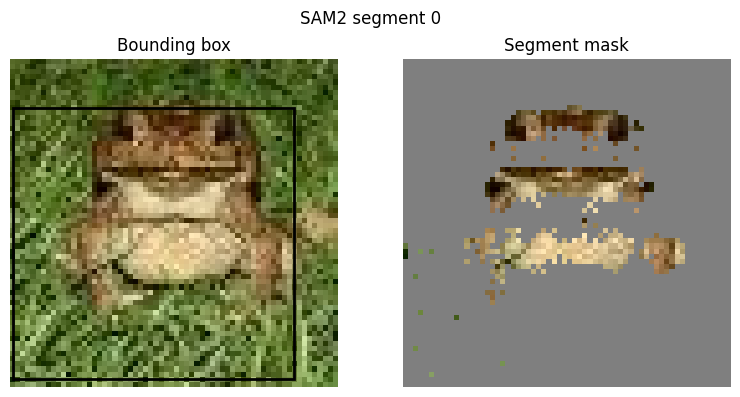

Segment 1: bbox=[0, 0, 64, 64]


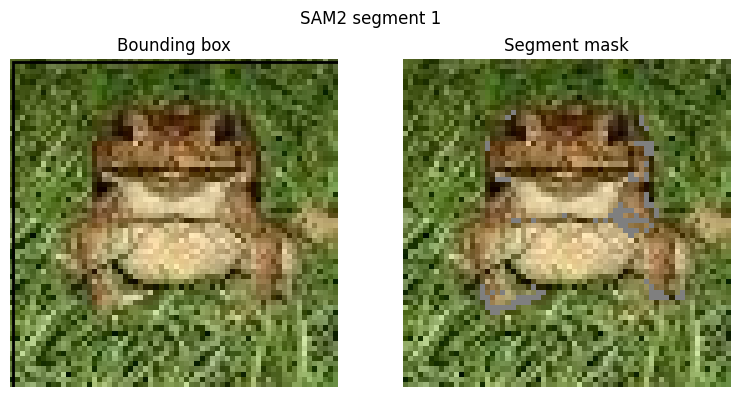

Segment 2: bbox=[0, 0, 64, 64]


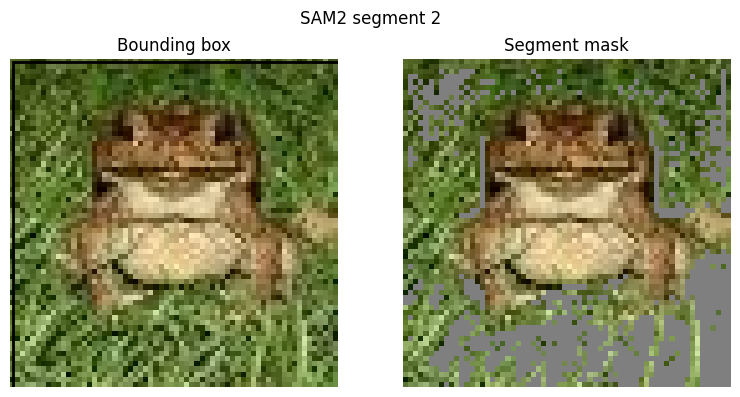

In [17]:
segments = run_segmentation_model(image_np, grid_size=6, score_threshold=0.0)
print(f"Found {len(segments)} segments")
for i, seg in enumerate(segments):
    print(f"Segment {i}: bbox={seg['bbox']}")
    show_segment_with_bbox(image_np, seg, title=f"SAM2 segment {i}")

Chosen segment: 0
Dilated bbox: [0, 7, 57, 64]


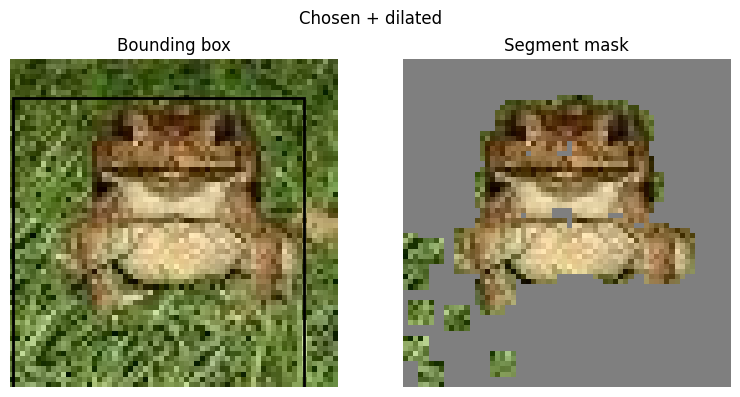

In [18]:
from scipy.ndimage import binary_dilation

SEGMENT_IDX = 0          # <-- change this manually after you look at the plots
DILATION_RADIUS = 2      # pixels; 0 means no dilation

chosen_segment = segments[SEGMENT_IDX]
bbox = chosen_segment["bbox"]
mask = chosen_segment["mask"]

if DILATION_RADIUS > 0:
    struct = np.ones((2 * DILATION_RADIUS + 1, 2 * DILATION_RADIUS + 1), dtype=bool)
    mask = binary_dilation(mask, structure=struct)

# recompute bbox from dilated mask, in case it changed
ys, xs = np.where(mask)
y_min, y_max = ys.min(), ys.max() + 1
x_min, x_max = xs.min(), xs.max() + 1
bbox = [int(x_min), int(y_min), int(x_max), int(y_max)]

print("Chosen segment:", SEGMENT_IDX)
print("Dilated bbox:", bbox)

show_segment_with_bbox(image_np, {"bbox": bbox, "mask": mask}, title="Chosen + dilated")

In [19]:
def pixel_index(y, x, c, H, W, C):
    """
    Given y, x, channel c in an image (H, W, C),
    return the flat index assuming layout (C, H, W) flattened.
    """
    return c * H * W + y * W + x

In [20]:
H, W, C = image_np.shape
N = H * W * C
EPSILON = 0.03

base = image_np  # in [0,1]
lb = base.copy()
ub = base.copy()

for y in range(H):
    for x in range(W):
        inside = mask[y, x]
        for c in range(C):
            idx = pixel_index(y, x, c, H, W, C)
            val = base[y, x, c]
            if inside:
                lb[y, x, c] = max(0.0, val - EPSILON)
                ub[y, x, c] = min(1.0, val + EPSILON)
            else:
                # outside: keep exact value
                lb[y, x, c] = val
                ub[y, x, c] = val

lb_flat = lb.transpose(2, 0, 1).reshape(-1)
ub_flat = ub.transpose(2, 0, 1).reshape(-1)

lb_flat.shape, ub_flat.shape

((12288,), (12288,))

In [27]:
def write_vnnlib_for_segment(lb_flat, ub_flat, true_label, num_classes, out_path):
    out_path = Path(out_path)
    N = len(lb_flat)

    with out_path.open("w") as f:
        # Declare input variables
        for i in range(N):
            f.write(f"(declare-const X_{i} Real)\n")
        f.write("\n")

        # Input bounds
        for i in range(N):
            f.write(f"(assert (>= X_{i} {lb_flat[i]:.6f}))\n")
            f.write(f"(assert (<= X_{i} {ub_flat[i]:.6f}))\n")
        f.write("\n")

        # Output robustness constraints
        for k in range(num_classes):
            if k == true_label:
                continue
            # (output true_label) >= (output k)
            f.write(
                f"(assert (<= (- (output {k}) (output {true_label})) 0))\n"
            )

    print(f"Saved VNNLib property to: {out_path.resolve()}")

In [29]:
write_vnnlib_for_segment(
    lb_flat=lb_flat,
    ub_flat=ub_flat,
    true_label=TRUE_LABEL,
    num_classes=NUM_CLASSES,
    out_path=VNNLIB_OUT,
)

print(VNNLIB_OUT.read_text().splitlines()[:40])  # show first 40 lines

Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/scripts/segmented_property.vnnlib
['(declare-const X_0 Real)', '(declare-const X_1 Real)', '(declare-const X_2 Real)', '(declare-const X_3 Real)', '(declare-const X_4 Real)', '(declare-const X_5 Real)', '(declare-const X_6 Real)', '(declare-const X_7 Real)', '(declare-const X_8 Real)', '(declare-const X_9 Real)', '(declare-const X_10 Real)', '(declare-const X_11 Real)', '(declare-const X_12 Real)', '(declare-const X_13 Real)', '(declare-const X_14 Real)', '(declare-const X_15 Real)', '(declare-const X_16 Real)', '(declare-const X_17 Real)', '(declare-const X_18 Real)', '(declare-const X_19 Real)', '(declare-const X_20 Real)', '(declare-const X_21 Real)', '(declare-const X_22 Real)', '(declare-const X_23 Real)', '(declare-const X_24 Real)', '(declare-const X_25 Real)', '(declare-const X_26 Real)', '(declare-const X_27 Real)', '(declare-const X_28 Real)', '(declare-const X_29 Real)', '(declare-const X_30 Real)', '(declare-const X_31

In [30]:
global_eps = EPSILON
lb_global = np.clip(image_np - global_eps, 0.0, 1.0)
ub_global = np.clip(image_np + global_eps, 0.0, 1.0)

lb_global_flat = lb_global.transpose(2, 0, 1).reshape(-1)
ub_global_flat = ub_global.transpose(2, 0, 1).reshape(-1)

VNNLIB_ORIG = Path("original_eps_property.vnnlib")
write_vnnlib_for_segment(
    lb_flat=lb_global_flat,
    ub_flat=ub_global_flat,
    true_label=TRUE_LABEL,
    num_classes=NUM_CLASSES,
    out_path=VNNLIB_ORIG,
)

Saved VNNLib property to: /Users/zd3504phd/Desktop/XAIV/scripts/original_eps_property.vnnlib
